# Äriregistri andmete analüüs

In [42]:
import duckdb
import pandas as pd
import seaborn as sns

## Ettevõtte lihtanmded

In [14]:
juriidilised_isikud = pd.read_csv("ettevotja_rekvisiidid__lihtandmed.csv", sep=";")
juriidilised_isikud

,nimi,ariregistri_kood,ettevotja_oiguslik_vorm,ettevotja_oigusliku_vormi_alaliik,kmkr_nr,ettevotja_staatus,ettevotja_staatus_tekstina,ettevotja_esmakande_kpv,ettevotja_aadress,asukoht_ettevotja_aadressis,asukoha_ehak_kood,asukoha_ehak_tekstina,indeks_ettevotja_aadressis,ads_adr_id,ads_ads_oid,ads_normaliseeritud_taisaadress,teabesysteemi_link
0,007 Agent & Partners OÜ,16752073,Osaühing,NaN,NaN,R,Registrisse kantud,05.06.2023,NaN,Regati pst 12,596.0,"Pirita linnaosa, Tallinn, Harju maakond",11911,2363082.0,NaN,"Harju maakond, Tallinn, Pirita linnaosa, Regat...",https://ariregister.rik.ee/est/company/16752073
1,007 Autohaus osaühing,11694365,Osaühing,NaN,EE101335276,R,Registrisse kantud,30.07.2009,NaN,Turu tn 34,8151.0,"Tartu linn, Tartu linn, Tartu maakond",51004,3047590.0,NaN,"Tartu maakond, Tartu linn, Tartu linn, Turu tn 34",https://ariregister.rik.ee/est/company/11694365
2,007Draiv OÜ,17064033,Osaühing,NaN,NaN,R,Registrisse kantud,06.09.2024,NaN,Tööstuse tn 81-24,614.0,"Põhja-Tallinna linnaosa, Tallinn, Harju maakond",10416,2320820.0,NaN,"Harju maakond, Tallinn, Põhja-Tallinna linnaos...",https://ariregister.rik.ee/est/company/17064033
3,011 HOUSE OÜ,16913932,Osaühing,NaN,EE102709775,R,Registrisse kantud,05.02.2024,NaN,Tööstuse tn 75-71,614.0,"Põhja-Tallinna linnaosa, Tallinn, Harju maakond",10416,2286871.0,NaN,"Harju maakond, Tallinn, Põhja-Tallinna linnaos...",https://ariregister.rik.ee/est/company/16913932
4,01Arvutiabi OÜ,14112620,Osaühing,NaN,NaN,R,Registrisse kantud,13.09.2016,NaN,Aru tn 19-5,614.0,"Põhja-Tallinna linnaosa, Tallinn, Harju maakond",10318,2283769.0,NaN,"Harju maakond, Tallinn, Põhja-Tallinna linnaos...",https://ariregister.rik.ee/est/company/14112620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377859,YYLEAF OÜ,16975465,Osaühing,NaN,NaN,R,Registrisse kantud,26.04.2024,NaN,Vesivärava tn 50-301,298.0,"Kesklinna linnaosa, Tallinn, Harju maakond",10152,3409965.0,NaN,"Harju maakond, Tallinn, Kesklinna linnaosa, Ve...",https://ariregister.rik.ee/est/company/16975465
377860,Y&Y LOGISTIC GROUP OÜ,11865358,Osaühing,NaN,EE101373351,R,Registrisse kantud,05.01.2010,NaN,Hommiku tee 11,8009.0,"Tabasalu alevik, Harku vald, Harju maakond",76901,1692795.0,NaN,"Harju maakond, Harku vald, Tabasalu alevik, Ho...",https://ariregister.rik.ee/est/company/11865358
377861,YYMT OÜ,16965099,Osaühing,NaN,NaN,R,Registrisse kantud,12.04.2024,NaN,Villardi tn 22-4,298.0,"Kesklinna linnaosa, Tallinn, Harju maakond",10136,2266360.0,NaN,"Harju maakond, Tallinn, Kesklinna linnaosa, Vi...",https://ariregister.rik.ee/est/company/16965099
377862,YYRIX KODU OÜ,14331396,Osaühing,NaN,NaN,R,Registrisse kantud,13.09.2017,NaN,Karsti tn 9-5,482.0,"Mustamäe linnaosa, Tallinn, Harju maakond",11625,2344069.0,NaN,"Harju maakond, Tallinn, Mustamäe linnaosa, Kar...",https://ariregister.rik.ee/est/company/14331396


In [15]:
for col in juriidilised_isikud.columns:
    print(f"{col},")

nimi,
ariregistri_kood,
ettevotja_oiguslik_vorm,
ettevotja_oigusliku_vormi_alaliik,
kmkr_nr,
ettevotja_staatus,
ettevotja_staatus_tekstina,
ettevotja_esmakande_kpv,
ettevotja_aadress,
asukoht_ettevotja_aadressis,
asukoha_ehak_kood,
asukoha_ehak_tekstina,
indeks_ettevotja_aadressis,
ads_adr_id,
ads_ads_oid,
ads_normaliseeritud_taisaadress,
teabesysteemi_link,


In [38]:
juriidilised_isikud = duckdb.sql("""
    SELECT
        nimi,
        ariregistri_kood,
        ettevotja_oiguslik_vorm,
        ettevotja_oigusliku_vormi_alaliik,
        kmkr_nr,
        ettevotja_staatus_tekstina,
        ettevotja_esmakande_kpv,
        asukoha_ehak_tekstina
    FROM 'ettevotja_rekvisiidid__lihtandmed.csv'
""")
juriidilised_isikud

┌──────────────────────────────┬──────────────────┬─────────────────────────┬───────────────────────────────────┬─────────────┬────────────────────────────┬─────────────────────────┬─────────────────────────────────────────────────┐
│             nimi             │ ariregistri_kood │ ettevotja_oiguslik_vorm │ ettevotja_oigusliku_vormi_alaliik │   kmkr_nr   │ ettevotja_staatus_tekstina │ ettevotja_esmakande_kpv │              asukoha_ehak_tekstina              │
│           varchar            │      int64       │         varchar         │              varchar              │   varchar   │          varchar           │          date           │                     varchar                     │
├──────────────────────────────┼──────────────────┼─────────────────────────┼───────────────────────────────────┼─────────────┼────────────────────────────┼─────────────────────────┼─────────────────────────────────────────────────┤
│ 007 Agent & Partners OÜ      │         16752073 │ Osaühing        

## Majandusaasta aruannete üldanmded

In [21]:
yearly_report_metadata = duckdb.sql("""
    SELECT
        report_id,
        registrikood,
        "valitud aruanne kategooria"
    FROM '1.aruannete_yldandmed_kuni_31082026.csv'
    WHERE aruandeaasta = 2025
""")
yearly_report_metadata


┌───────────┬──────────────┬──────────────────────────────┐
│ report_id │ registrikood │  valitud aruanne kategooria  │
│   int64   │    int64     │           varchar            │
├───────────┼──────────────┼──────────────────────────────┤
│   3423341 │     10000018 │ Suurettevõtja                │
│   3614052 │     10000024 │ Mikroettevõtja               │
│   3460373 │     10000127 │ Mikroettevõtja               │
│   3462722 │     10000165 │ Väikeettevõtja               │
│   3392900 │     10000248 │ Keskmise suurusega ettevõtja │
│   3462736 │     10000356 │ Väikeettevõtja               │
│   3405308 │     10000372 │ Keskmise suurusega ettevõtja │
│   3455027 │     10000395 │ Mikroettevõtja               │
│   3598998 │     10000449 │ Mikroettevõtja               │
│   3537961 │     10000455 │ Mikroettevõtja               │
│      ·    │         ·    │       ·                      │
│      ·    │         ·    │       ·                      │
│      ·    │         ·    │       ·    

## 2025 aasta aruande andmed

In [27]:
duckdb.sql("""
    SELECT DISTINCT tabel, elemendi_label, elemendi_nimetus
    FROM '4.2025_aruannete_elemendid_kuni_31082026.csv' 
""").df().to_csv("majandusaasta_mõõdikud.csv", index=False)

In [28]:
duckdb.sql("""
    COPY (
        SELECT DISTINCT tabel, elemendi_label, elemendi_nimetus
        FROM '4.2025_aruannete_elemendid_kuni_31082026.csv'
    ) TO 'majandusaasta_mõõdikud.csv' (HEADER, DELIMITER ',');
""")



In [29]:
duckdb.sql("""
    SELECT DISTINCT tabel, elemendi_label, elemendi_nimetus
    FROM '4.2025_aruannete_elemendid_kuni_31082026.csv'
""")


┌────────────────────────────────────────────────────┬──────────────────────────────────────────────┬───────────────────────────────────────┐
│                       tabel                        │                elemendi_label                │           elemendi_nimetus            │
│                      varchar                       │                   varchar                    │                varchar                │
├────────────────────────────────────────────────────┼──────────────────────────────────────────────┼───────────────────────────────────────┤
│ Kasumiaruanne skeem 1                              │ Põhivarade kulum ja väärtuse langus          │ DepreciationAndImpairmentLossReversal │
│ Kasumiaruanne skeem 1                              │ Tööjõukulud                                  │ EmployeeExpense                       │
│ Bilanss                                            │ Käibevarad                                   │ CurrentAssets                         │
│ Bila

In [34]:
assets = duckdb.sql("""
    SELECT
        report_id,
        vaartus AS assets
    FROM '4.2025_aruannete_elemendid_kuni_31082026.csv'
    WHERE tabel = 'Bilanss' AND elemendi_label = 'Varad'
""")
assets


┌───────────┬────────────┐
│ report_id │   assets   │
│   int64   │   double   │
├───────────┼────────────┤
│   3088786 │        0.0 │
│   3098781 │  8289866.0 │
│   3118641 │      185.0 │
│   3121462 │        0.0 │
│   3125627 │        0.0 │
│   3137836 │   925519.0 │
│   3143927 │     7959.0 │
│   3151806 │        0.0 │
│   3154372 │   264478.0 │
│   3158876 │    33303.0 │
│      ·    │        ·   │
│      ·    │        ·   │
│      ·    │        ·   │
│   3396754 │     8419.0 │
│   3396755 │    17761.0 │
│   3396756 │   118449.0 │
│   3396758 │  1460279.0 │
│   3396759 │    40203.0 │
│   3396760 │ 13100567.0 │
│   3396761 │    26856.0 │
│   3396762 │   289236.0 │
│   3396763 │     4510.0 │
│   3396765 │     2951.0 │
├───────────┴────────────┤
│ ? rows       2 columns │
└────────────────────────┘

In [62]:
equity = duckdb.sql("""
    SELECT
        report_id,
        avg(vaartus) AS omakapital
    FROM '4.2025_aruannete_elemendid_kuni_31082026.csv'
    WHERE elemendi_label = 'Omakapital'
    GROUP BY report_id
""")
equity

┌───────────┬────────────┐
│ report_id │ omakapital │
│   int64   │   double   │
├───────────┼────────────┤
│   3435884 │    51113.0 │
│   3435885 │   416734.0 │
│   3435894 │     -724.0 │
│   3435923 │     2528.0 │
│   3435952 │     6181.0 │
│   3435970 │     3157.0 │
│   3435979 │     4283.0 │
│   3435984 │    57684.0 │
│   3435986 │     9272.0 │
│   3435991 │    21674.0 │
│      ·    │       ·    │
│      ·    │       ·    │
│      ·    │       ·    │
│   3584469 │    27881.0 │
│   3584486 │     4188.0 │
│   3584600 │      235.0 │
│   3584678 │       20.0 │
│   3584700 │     2751.0 │
│   3584706 │     2955.0 │
│   3584724 │   703498.0 │
│   3584761 │        0.0 │
│   3584822 │     2739.0 │
│   3584862 │   117540.0 │
├───────────┴────────────┤
│ ? rows       2 columns │
└────────────────────────┘

## Tabelite kokku ühendamine

In [63]:
data = duckdb.sql("""
    SELECT juriidilised_isikud.*,
            yearly_report_metadata."valitud aruanne kategooria" AS aruande_kategooria,
            assets.assets,
            equity.omakapital
    FROM juriidilised_isikud
        INNER JOIN yearly_report_metadata ON juriidilised_isikud.ariregistri_kood = yearly_report_metadata.registrikood
        LEFT JOIN assets ON assets.report_id = yearly_report_metadata.report_id
        LEFT JOIN equity ON equity.report_id = yearly_report_metadata.report_id
""").df()
data

,nimi,ariregistri_kood,ettevotja_oiguslik_vorm,ettevotja_oigusliku_vormi_alaliik,kmkr_nr,ettevotja_staatus_tekstina,ettevotja_esmakande_kpv,asukoha_ehak_tekstina,aruande_kategooria,assets,omakapital
0,Entertechia OÜ,16772555,Osaühing,None,EE102664904,Registrisse kantud,2023-07-06,"Lasnamäe linnaosa, Tallinn, Harju maakond",Väikeettevõtja,1929710.0,1310247.0
1,Osaühing Soojusabi,11465015,Osaühing,None,EE101240060,Registrisse kantud,2008-04-04,"Rapla linn, Rapla vald, Rapla maakond",Mikroettevõtja,72358.0,12581.0
2,Kalda tee 26 OÜ,16553014,Osaühing,None,EE102582109,Registrisse kantud,2022-08-12,"Tartu linn, Tartu linn, Tartu maakond",Väikeettevõtja,2392069.0,190995.0
3,Osaühing Stellum Valveseadmed,10325795,Osaühing,None,EE100338656,Registrisse kantud,1997-11-14,"Kristiine linnaosa, Tallinn, Harju maakond",Väikeettevõtja,50356.0,21264.0
4,Auto VOD OÜ,11232357,Osaühing,None,None,Registrisse kantud,2006-04-11,"Elva linn, Elva vald, Tartu maakond",Mikroettevõtja,2501.0,2501.0
...,...,...,...,...,...,...,...,...,...,...,...
234397,"Lääneranna vald, Kirbla küla, Luha tee 3 korte...",80007813,Korteriühistu,None,None,Registrisse kantud,1997-05-20,None,Mikroettevõtja,NaN,NaN
234398,"Lääneranna vald, Kirbla küla, Vana tee 2 korte...",80007453,Korteriühistu,None,None,Registrisse kantud,1997-05-08,None,Mikroettevõtja,NaN,NaN
234399,Õie Lätti nimeline Heategevusfond,80550430,Mittetulundusühing,tavaline mittetulundusühing,None,Registrisse kantud,2018-05-15,"Viljandi linn, Viljandi maakond",Mikroettevõtja,NaN,NaN
234400,Ühendatud Venemaa kodanike ühiskondlike organi...,80306345,Mittetulundusühing,tavaline mittetulundusühing,None,Registrisse kantud,2010-03-31,None,Mikroettevõtja,NaN,NaN


[None]

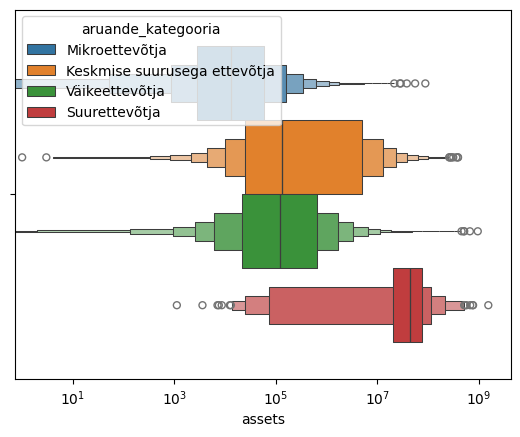

In [61]:
ax = sns.boxenplot(data, x="assets", hue="aruande_kategooria")
ax.set(xscale="log")


In [58]:
duckdb.sql("""
    SELECT *
    FROM data
    ORDER BY assets DESC
    LIMIT 20
""")

┌─────────────────────────────────────────────────┬──────────────────┬─────────────────────────┬───────────────────────────────────┬─────────────┬────────────────────────────┬─────────────────────────┬─────────────────────────────────────────────────────┬──────────────────────────────┬──────────────┐
│                      nimi                       │ ariregistri_kood │ ettevotja_oiguslik_vorm │ ettevotja_oigusliku_vormi_alaliik │   kmkr_nr   │ ettevotja_staatus_tekstina │ ettevotja_esmakande_kpv │                asukoha_ehak_tekstina                │      aruande_kategooria      │    assets    │
│                     varchar                     │      int64       │         varchar         │              varchar              │   varchar   │          varchar           │        timestamp        │                       varchar                       │           varchar            │    double    │
├─────────────────────────────────────────────────┼──────────────────┼────────────────────────

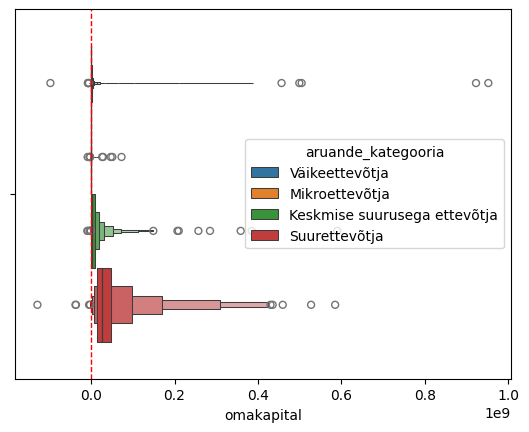

In [68]:
ax = sns.boxenplot(data, x="omakapital", hue="aruande_kategooria")
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
#ax.set(xscale="log")


In [72]:
duckdb.sql("""
    SELECT *
    FROM data
    ORDER BY omakapital 
    LIMIT 20
""")


┌─────────────────────────────────┬──────────────────┬─────────────────────────┬───────────────────────────────────┬─────────────┬────────────────────────────┬─────────────────────────┬──────────────────────────────────────────────────┬──────────────────────────────┬─────────────┬──────────────┐
│              nimi               │ ariregistri_kood │ ettevotja_oiguslik_vorm │ ettevotja_oigusliku_vormi_alaliik │   kmkr_nr   │ ettevotja_staatus_tekstina │ ettevotja_esmakande_kpv │              asukoha_ehak_tekstina               │      aruande_kategooria      │   assets    │  omakapital  │
│             varchar             │      int64       │         varchar         │              varchar              │   varchar   │          varchar           │        timestamp        │                     varchar                      │           varchar            │   double    │    double    │
├─────────────────────────────────┼──────────────────┼─────────────────────────┼─────────────────────────────

<Axes: xlabel='omakapital', ylabel='assets'>

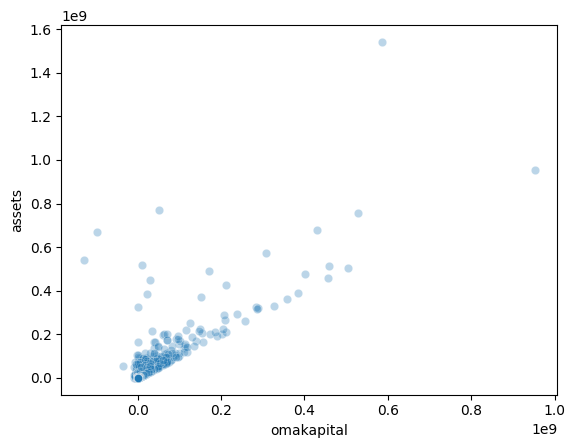

In [ ]:
sns.scatterplot(data, x="omakapital", y="assets", alpha=0.3)


<Axes: xlabel='omakapital', ylabel='assets'>

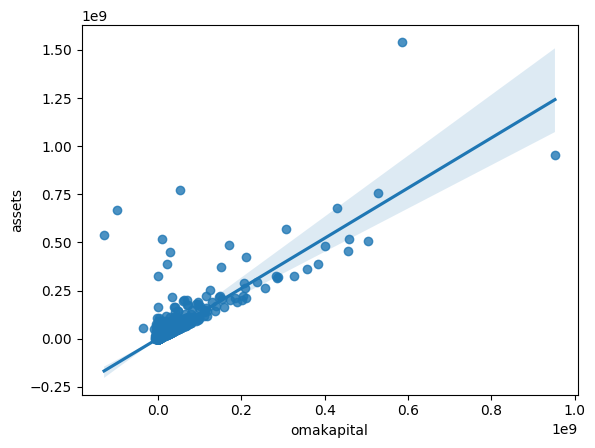

In [78]:
sns.regplot(data, x="omakapital", y="assets")